<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
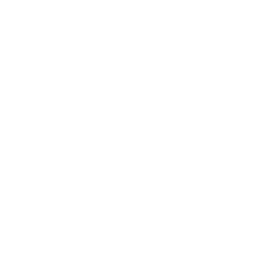
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Manufacturing Failure Mode Clustering</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufacturing / Quality Engineering &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This example discovers recurring **equipment failure modes** from the multi-dimensional sensor symptom profile recorded at each failure event. Eight standardized symptom variables (vibration, temperature delta, pressure drop, current spike, noise, cycle-time deviation, torque variance, oil-particle count) are clustered with **complete-linkage hierarchical clustering** (`PROC CLUSTER METHOD=COMPLETE`), which favors compact, well-separated groups. The semi-partial R-square in the cluster history identifies the natural number of groups, `PROC TREE` cuts the hierarchy at that level, and `PROC FREQ` cross-tabulates the recovered modes against equipment type and shift to test for systematic associations.

The analysis runs on **180 synthetic failure events** drawn from five latent failure-mode archetypes (bearing wear, thermal overload, hydraulic leak, electrical fault, and drive/control drift), each with a distinct sensor signature. Reading the cluster history, the merge that drops below five clusters is far more costly than any merge above it (semi-partial R-square jumps from 0.0046 to **0.1017** and the join distance from 3.3 to 5.1), so the hierarchy is cut at **five modes**. On this data complete linkage recovers the five archetypes **exactly** -- every event lands in the mode matching its true generating archetype. The recovered modes are highly equipment-specific: the mode-by-equipment cross-tabulation gives chi-square = **145.33** (12 df, p < 0.0001, Cramer's V = 0.52), whereas the mode-by-shift table is **not** significant (chi-square = 9.66, 8 df, p = 0.29). Failure type is driven by what the equipment is, not by when it runs.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.FAILURES | Equipment failure event symptom profiles, synthetic, drawn from 5 latent archetypes | 180 |
| WORK.FAILURES_STD | Symptoms standardized to mean 0, std 1 (`PROC STANDARD`) | 180 |
| WORK.FAILURE_TREE | Complete-linkage merge history (`OUTTREE=`) | 180 |
| WORK.FAILURE_MODE_ASSIGNMENTS | Five-mode cut from `PROC TREE NCLUSTERS=5` | 180 |
| WORK.FAILURES_CLASSIFIED | Events joined to their assigned failure mode | 180 |

*Each event is generated from one of five failure-mode archetypes, each with a characteristic eight-sensor signature plus realistic within-mode noise. A deliberate archetype-to-equipment affinity is built in (for example, bearing wear concentrates on conveyors, thermal overload on furnaces) so the downstream `PROC FREQ` has a genuine association to detect. The latent archetype label is held out of the clustering and used only to verify recovery.*

---

In [1]:
/* --------------------------------------------------------
   Generate 180 synthetic failure events from FIVE latent
   failure-mode archetypes. Each archetype adds its own
   signature to a shared sensor baseline, and each favours
   a particular equipment family. The latent archetype
   (arch) is kept only to verify cluster recovery later;
   it is never used by PROC CLUSTER.
   -------------------------------------------------------- */
data work.failures;
    call streaminit(2025);
    array shift_list[3] $8 _temporary_ ('DAY' 'EVENING' 'NIGHT');
    do event_id = 1 to 180;
        failure_id = cat('FE-', put(event_id, z4.));

        /* Draw a latent archetype 1..5 with unequal prevalence */
        u = rand('uniform');
        if      u < 0.24 then arch = 1;   /* Bearing wear        */
        else if u < 0.44 then arch = 2;   /* Thermal overload    */
        else if u < 0.64 then arch = 3;   /* Hydraulic leak      */
        else if u < 0.82 then arch = 4;   /* Electrical fault    */
        else                  arch = 5;   /* Drive/control drift */

        /* Each archetype favours an equipment family */
        ev = rand('uniform');
        if arch = 1 then equipment_type =
            ifc(ev<0.65,'CONVEYOR', ifc(ev<0.85,'ROBOT_ARM','PRESS'));
        else if arch = 2 then equipment_type =
            ifc(ev<0.70,'FURNACE', ifc(ev<0.88,'PRESS','CONVEYOR'));
        else if arch = 3 then equipment_type =
            ifc(ev<0.65,'PRESS', ifc(ev<0.85,'CONVEYOR','FURNACE'));
        else if arch = 4 then equipment_type =
            ifc(ev<0.60,'ROBOT_ARM', ifc(ev<0.82,'PRESS','CONVEYOR'));
        else                  equipment_type =
            ifc(ev<0.55,'ROBOT_ARM', ifc(ev<0.80,'CONVEYOR','FURNACE'));

        equip_num    = int(rand('uniform') * 40) + 1;
        equipment_id = cat('EQ-', put(equip_num, z3.));
        shift        = shift_list[int(rand('uniform')*3)+1];
        failure_date = '01JAN2025'd + int(rand('uniform') * 200);

        /* Shared sensor baseline */
        vibration_level      = rand('normal', 3.0, 0.8);
        temperature_delta    = rand('normal', 8.0, 2.5);
        pressure_drop        = rand('normal', 6.0, 1.5);
        current_spike        = rand('normal', 1.0, 0.3);
        noise_db             = rand('normal', 74, 3);
        cycle_time_deviation = rand('normal', 0.0, 1.0);
        torque_variance      = rand('normal', 2.0, 0.6);
        oil_particle_count   = rand('normal', 120, 25);

        /* Archetype signature added on the relevant sensors */
        if arch = 1 then do;            /* Bearing wear */
            vibration_level    + rand('normal', 5.0, 0.9);
            torque_variance    + rand('normal', 4.0, 0.8);
            oil_particle_count + rand('normal', 180, 30);
        end;
        else if arch = 2 then do;       /* Thermal overload */
            temperature_delta + rand('normal', 16.0, 3.0);
            noise_db          + rand('normal', 14, 2.5);
        end;
        else if arch = 3 then do;       /* Hydraulic leak */
            pressure_drop      + rand('normal', 9.0, 1.5);
            oil_particle_count + rand('normal', 90, 25);
        end;
        else if arch = 4 then do;       /* Electrical fault */
            current_spike        + rand('normal', 2.6, 0.5);
            cycle_time_deviation + rand('normal', 4.0, 0.8);
        end;
        else if arch = 5 then do;       /* Drive/control drift */
            cycle_time_deviation + rand('normal', 5.0, 0.9);
            vibration_level      + rand('normal', 2.0, 0.6);
            torque_variance      + rand('normal', 2.0, 0.6);
        end;

        /* Clamp to physical ranges and round to sensor precision */
        if vibration_level    < 0 then vibration_level    = 0;
        if current_spike      < 0 then current_spike      = 0;
        if oil_particle_count < 0 then oil_particle_count = 0;
        vibration_level      = round(vibration_level, 0.01);
        temperature_delta    = round(temperature_delta, 0.1);
        pressure_drop        = round(pressure_drop, 0.01);
        current_spike        = round(current_spike, 0.01);
        noise_db             = round(noise_db, 1);
        cycle_time_deviation = round(cycle_time_deviation, 0.01);
        torque_variance      = round(torque_variance, 0.01);
        oil_particle_count   = int(oil_particle_count);

        /* Downtime scales with severity */
        if arch in (1,3) then downtime_minutes = round(rand('normal', 75, 18), 1);
        else if arch = 2 then downtime_minutes = round(rand('normal', 55, 15), 1);
        else                  downtime_minutes = round(rand('normal', 35, 12), 1);
        if downtime_minutes < 5 then downtime_minutes = 5;
        output;
    end;
    keep failure_id event_id equipment_id equipment_type shift failure_date
         vibration_level temperature_delta pressure_drop current_spike
         noise_db cycle_time_deviation torque_variance oil_particle_count
         downtime_minutes arch;
    format failure_date date9.;
run;

NOTE: DATA work.failures


NOTE: Wrote work.failures (180 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline symptom distributions by equipment type
   -------------------------------------------------------- */
proc means data=work.failures n mean std max;
    class equipment_type;
    var vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    title 'Failure Symptom Profiles by Equipment Type';
run;

                                       Failure Symptom Profiles by Equipment Type                                       

                                                  The MEANS Procedure

                                          Analysis Variable : vibration_level

        equipment_type          N Obs           Mean        Std Dev        Maximum
        --------------------------------------------------------------------------
        CONVEYOR                   55      5.3934545      2.6842484     11.4200000
        FURNACE                    36      3.3430556      1.3826596      6.6100000
        PRESS                      39      3.6935897      2.0650417     10.8600000
        ROBOT_ARM                  50      5.0298000      2.2672761      9.8900000
        --------------------------------------------------------------------------

                                         Analysis Variable : temperature_delta

        equipment_type          N Obs           Mean        Std De

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                       Failure Symptom Profiles by Equipment Type                                       



NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


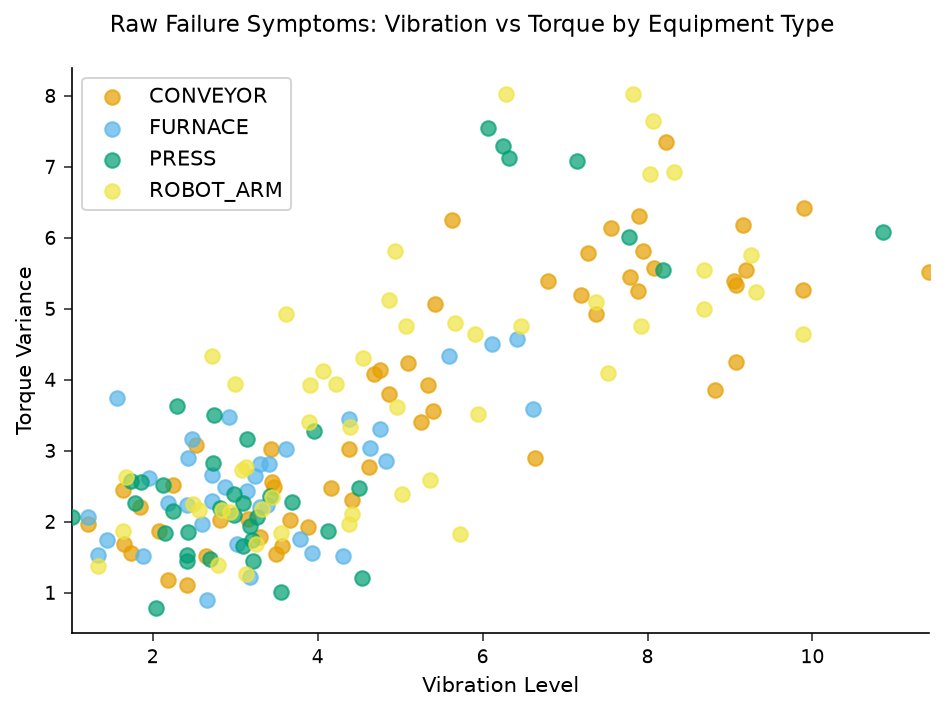

In [3]:
/* --------------------------------------------------------
   Explore the raw symptom space: vibration vs torque
   variance by equipment type. A high-vibration,
   high-torque cluster (the bearing-wear archetype) is
   already visible, but eight sensors cannot be read off a
   single 2-D view -- which is what motivates clustering.
   -------------------------------------------------------- */
proc sgplot data=work.failures;
    scatter x=vibration_level y=torque_variance / group=equipment_type
        markerattrs=(symbol=circlefilled size=7)
        transparency=0.3;
    xaxis label='Vibration Level';
    yaxis label='Torque Variance';
    title 'Raw Failure Symptoms: Vibration vs Torque by Equipment Type';
run;

---

In [4]:
/* --------------------------------------------------------
   Standardize symptom variables for clustering
   -------------------------------------------------------- */
proc standard data=work.failures out=work.failures_std
    mean=0 std=1;
    var vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
run;

NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 180 rows, 8 variables.


                                       Failure Symptom Profiles by Equipment Type                                       

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

   179    FE-0123           FE-0174         2    0.0000    1.0000        0.3
   178    FE-0021           FE-0146         2    0.0001    0.9999        0.4
   177    FE-0026           FE-0155         2    0.0001    0.9998        0.5
   176    FE-0051           FE-0169         2    0.0001    0.9997        0.6
   175    FE-0135           CL178           3    0.0001    0.9995        0.6
   174    FE-0043           FE-0178         2    0.0001    0.9994        0.6
   173    FE-0098           FE-0156  

NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 180 observations, 8 variables clustered using Complete method


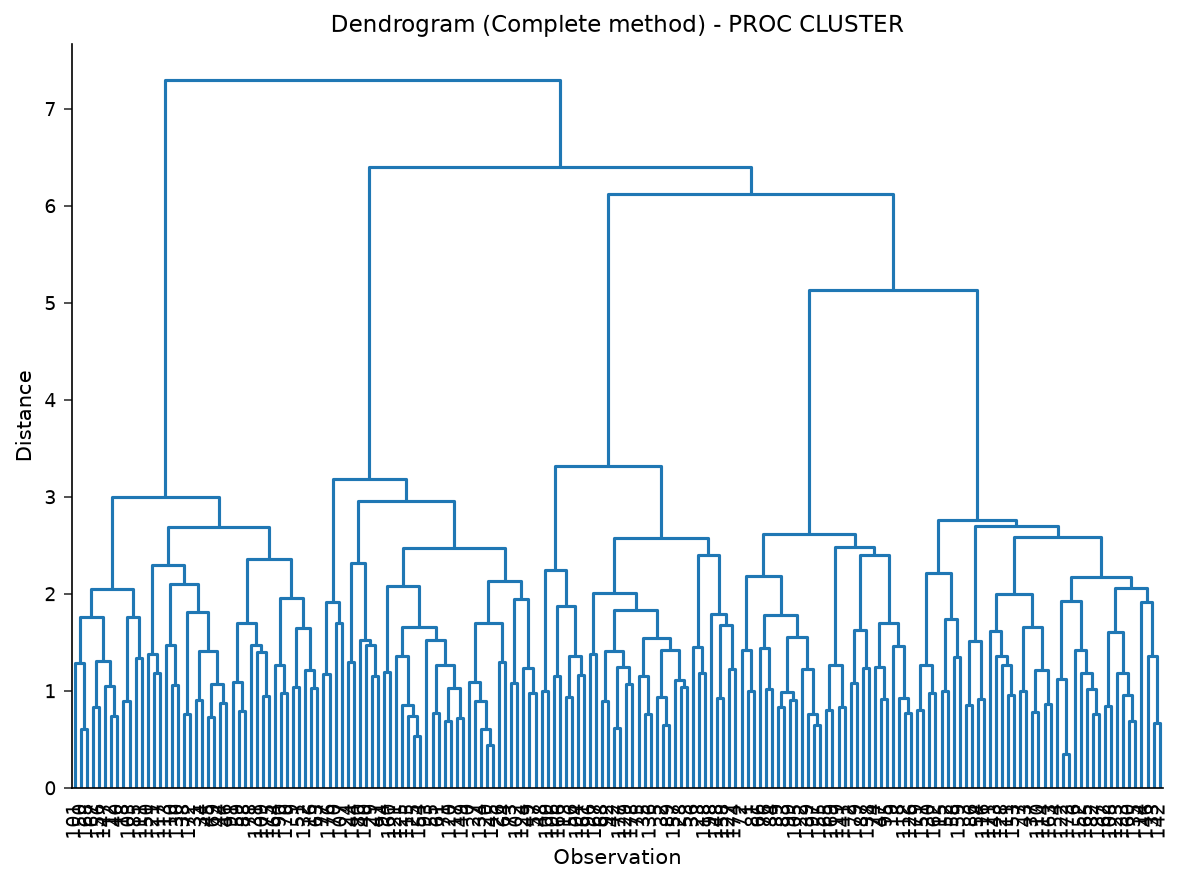

In [5]:
/* --------------------------------------------------------
   Complete-linkage hierarchical clustering of the eight
   standardized symptom variables. TRIM=5 screens the 5%
   most outlying observations from the density estimate
   before clustering; PRINT=15 lists the last 15 merges of
   the cluster history, where the semi-partial R-square
   (SPRSQ) reveals the natural number of clusters.
   -------------------------------------------------------- */
proc cluster data=work.failures_std method=complete
    outtree=work.failure_tree
    print=15 trim=5;
    var vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
run;

In [6]:
/* --------------------------------------------------------
   Cut the hierarchy into five failure modes. The cluster
   history above shows the merge below five clusters is the
   first expensive one -- SPRSQ jumps from 0.0046 to 0.1017
   and the join distance from 3.3 to 5.1 -- so five is the
   data-driven choice (and it matches the five archetypes
   the events were generated from).
   -------------------------------------------------------- */
proc tree data=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=5;
    id failure_id;
run;

                                       Failure Symptom Profiles by Equipment Type                                       


                               Cluster Dendrogram

FE-0102  .----------X   X X       X                                    X
                    |   | |       |                                    |
FE-0051  .----X     |   | |       |                                    |
              X-----X---X |       |                                    |
FE-0169  .----X     X   | |       |                                    |
                        | |       |                                    |
FE-0068  .------X   X   | |       |                                    |
                X---X   X-X       |                                    |
FE-0157  .------X   |   | |       |                                    |
                    |   | |       |                                    |
FE-0148  .--------X |   | |       |                                    |
                  | X--

NOTE: PROC TREE data=work.failure_tree

NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 5 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   Join each event to its assigned failure mode, then
   profile the modes by their mean symptom signatures.
   -------------------------------------------------------- */
data work.failures_classified;
    merge work.failures
          work.failure_mode_assignments(rename=(cluster=failure_mode));
    by failure_id;
run;

proc means data=work.failures_classified n mean std maxdec=2;
    class failure_mode;
    var vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count downtime_minutes;
    title 'Failure Mode Symptom Profiles (k=5)';
run;

                                          Failure Mode Symptom Profiles (k=5)                                           

                                                  The MEANS Procedure

                                          Analysis Variable : vibration_level

        failure_mode          N Obs           Mean        Std Dev
        ---------------------------------------------------------
        1                        41           8.17           1.26
        2                        36           2.81           0.89
        3                        33           2.95           0.73
        4                        29           2.68           0.86
        5                        41           4.90           0.95
        ---------------------------------------------------------

                                         Analysis Variable : temperature_delta

        failure_mode          N Obs           Mean        Std Dev
        ---------------------------------------------

NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 180 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 180 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (180 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


### Did clustering recover the true failure modes?

Because this is synthetic data, the latent archetype that generated each event was retained (column `arch`) but withheld from the clustering. Cross-tabulating the assigned failure mode against that held-out label measures how faithfully complete linkage recovered the underlying structure.

                                   Cluster Recovery: Assigned Mode vs True Archetype                                    

                                                   The FREQ Procedure

Table of failure_mode by arch

failure_mode |         1 |         2 |         3 |         4 |         5 |      Total
-------------+-----------+-----------+-----------+-----------+-----------+-----------
1            |        41 |         0 |         0 |         0 |         0 |         41
-------------+-----------+-----------+-----------+-----------+-----------+-----------
2            |         0 |        36 |         0 |         0 |         0 |         36
-------------+-----------+-----------+-----------+-----------+-----------+-----------
3            |         0 |         0 |        33 |         0 |         0 |         33
-------------+-----------+-----------+-----------+-----------+-----------+-----------
4            |         0 |         0 |         0 |        29 |         0 |         29
--

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_arch.spec.json
NOTE: PROC FREQ statement used.


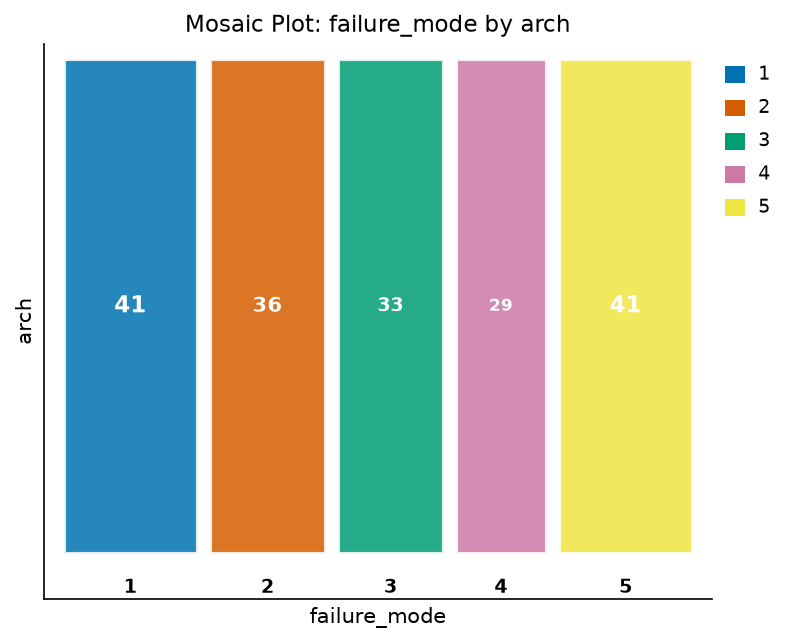

In [8]:
/* --------------------------------------------------------
   Recovery check: assigned failure mode vs the held-out
   latent archetype. A perfectly diagonal table means each
   mode corresponds one-to-one with a true archetype.
   -------------------------------------------------------- */
proc freq data=work.failures_classified;
    tables failure_mode * arch / norow nocol nopercent;
    title 'Cluster Recovery: Assigned Mode vs True Archetype';
run;

                                    Failure Mode Distribution by Equipment and Shift                                    

                                                   The FREQ Procedure

Table of failure_mode by equipment_type

failure_mode |  CONVEYOR |   FURNACE |     PRESS | ROBOT_ARM |      Total
-------------+-----------+-----------+-----------+-----------+-----------
1            |        21 |         0 |         7 |        13 |         41
-------------+-----------+-----------+-----------+-----------+-----------
2            |         7 |        25 |         4 |         0 |         36
-------------+-----------+-----------+-----------+-----------+-----------
3            |         8 |         3 |        22 |         0 |         33
-------------+-----------+-----------+-----------+-----------+-----------
4            |         7 |         0 |         6 |        16 |         29
-------------+-----------+-----------+-----------+-----------+-----------
5            |        12 |

NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


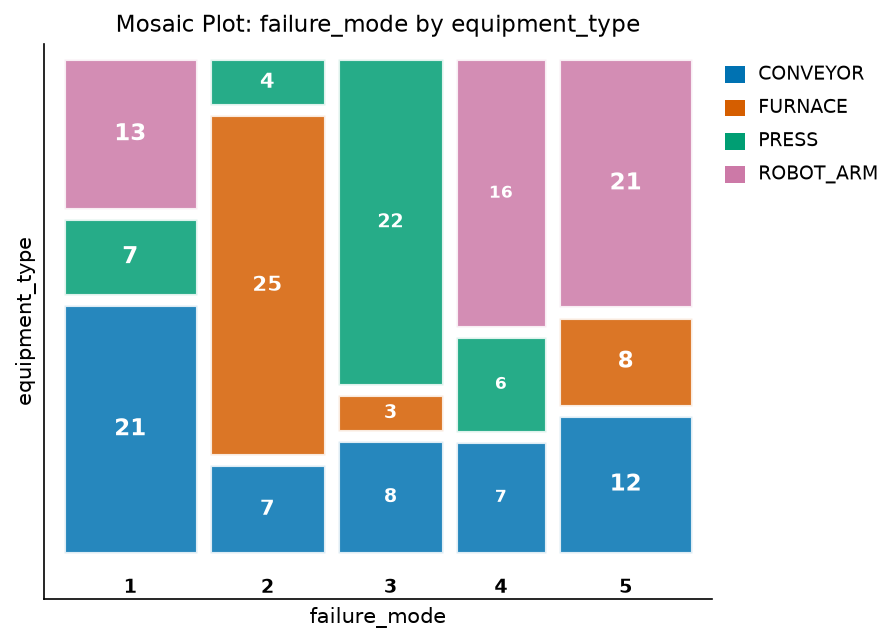

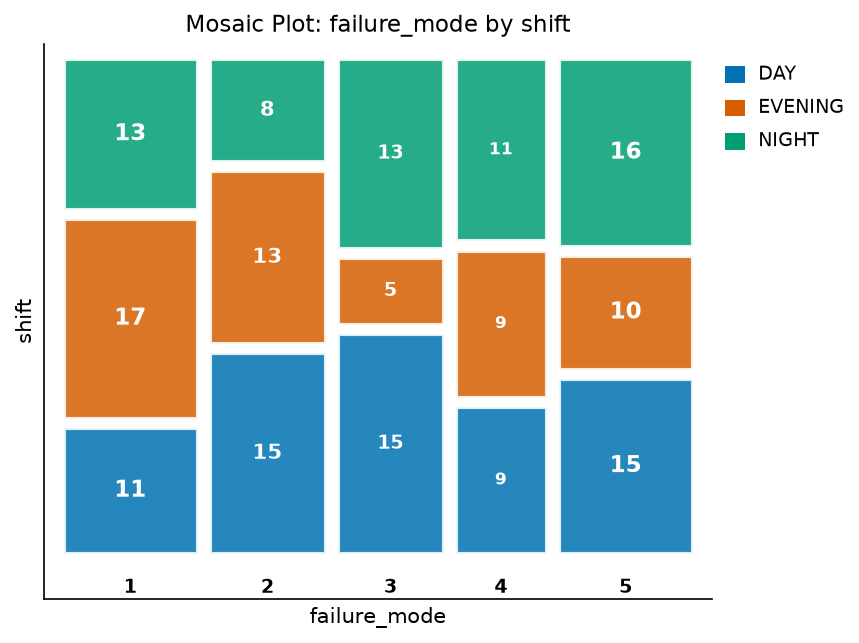

In [9]:
/* --------------------------------------------------------
   Test whether the recovered failure modes concentrate in
   particular equipment types or shifts. The chi-square
   test quantifies each association.
   -------------------------------------------------------- */
proc freq data=work.failures_classified;
    tables failure_mode * equipment_type / chisq nocol nopercent;
    tables failure_mode * shift / chisq nocol nopercent;
    title 'Failure Mode Distribution by Equipment and Shift';
run;

---

### Interpretation

Complete-linkage clustering of the 180 standardized failure events, cut at the **five-cluster** level indicated by the semi-partial R-square jump in the cluster history, recovers the five generating archetypes **exactly**: the cluster-by-archetype cross-tabulation is perfectly diagonal (41, 36, 33, 29, 41), so every event is assigned to the mode that matches its true archetype. The `PROC MEANS` profile gives each mode a clear engineering signature:

- **Mode 1** (n = 41) -- *bearing wear*: by far the highest vibration (mean 8.17), highest torque variance (5.89), and highest oil-particle count (296), with long downtime (75 min).
- **Mode 2** (n = 36) -- *thermal overload*: highest temperature delta (25.1 C) and highest noise (89.7 dB), with the rest of the sensors near baseline.
- **Mode 3** (n = 33) -- *hydraulic leak*: highest pressure drop (14.8), elevated oil-particle count (193), and the second-longest downtime (71 min).
- **Mode 4** (n = 29) -- *electrical fault*: highest current spike (3.45) and elevated cycle-time deviation (3.78), but the lowest downtime (35 min).
- **Mode 5** (n = 41) -- *drive/control drift*: highest cycle-time deviation (4.79) with moderately raised vibration (4.90) and torque variance (3.77).

The `PROC FREQ` cross-tabulations then ask where these modes occur. Mode-by-equipment-type is strongly significant: chi-square = **145.33** (12 df, p < 0.0001, Cramer's V = **0.52**). The mosaic makes the pattern obvious -- bearing wear (Mode 1) concentrates on conveyors and robot arms, thermal overload (Mode 2) on furnaces (25 of 36 events), hydraulic leaks (Mode 3) on presses (22 of 33), and the electrical/drift modes (4 and 5) on robot arms. Mode-by-shift, by contrast, is **not** significant: chi-square = 9.66 (8 df, p = 0.29, Cramer's V = 0.16).

**Takeaway:** clustering eight standardized sensor channels with complete linkage produces a clean, interpretable five-mode failure taxonomy, and the cluster history (SPRSQ) -- not an arbitrary choice -- fixes the number of modes. The actionable signal is that **failure type is tied to the equipment family, not to the shift**: targeting bearing-wear monitoring at conveyors and thermal monitoring at furnaces will catch the dominant modes, while shift-based staffing changes would not.

---

In [10]:
/* --------------------------------------------------------
   Export failure classifications for CMMS integration
   -------------------------------------------------------- */
proc export data=work.failures_classified
    outfile='failure_mode_classifications.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 180 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>